# Multi-View Aggregation: Fusing Predicted Gaussians into a Consistent 3D Scene

**Companion to:** [The Image-to-3D Landscape](https://artifocial.com/blog/image-to-3d-landscape-2026-apr-05)  
**Series:** 3D Gaussian Splatting (W14)  
**Difficulty:** Advanced

## Overview

In [NB 01](./01_image_to_gaussians.ipynb), we built an image→Gaussian decoder pipeline. In [NB 02](https://github.com/artifocial/tutorials/blob/main/2026-W14/02_novel_view_synthesis.ipynb), we observed that rendering a single-view prediction from novel angles quickly degrades in quality. **The cure: don't rely on one view. Use multiple views.**

This notebook solves the **multi-view aggregation problem**:
- Given N predicted Gaussian sets (one from each input view)
- Fuse them into a single, consistent 3D scene
- The result renders well from *all* angles, not just the training view

We'll implement **geometric fusion** (spatial proximity + parameter averaging) and show how iterative refinement improves consistency. This is a toy version of production systems like [SyncDreamer](https://arxiv.org/abs/2309.03453) and approaches hinted at in [Marble](https://www.worldlabs.ai/blog/marble-world-model).

## Setup

In [1]:
import shutil
import subprocess
import sys

# uv-first: use uv if available, fall back to pip
if shutil.which("uv"):
    subprocess.check_call(
        ["uv", "pip", "install", "--quiet", "--system", "numpy", "matplotlib"]
    )
else:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "numpy", "matplotlib"]
    )

import warnings

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

warnings.filterwarnings("ignore")

np.random.seed(42)
print("Dependencies loaded!")
print(f"NumPy version: {np.__version__}")

Dependencies loaded!
NumPy version: 2.2.6


> **Engineering Callout #0 (Meta): The `uv` Setup Trap**
>
> During initial testing, this notebook crashed on the very first cell. The install command used
> `uv pip install` (the fast Rust-based package manager), which fails in environments without a
> virtual environment unless you pass `--system`. The fix: fall back to `sys.executable -m pip`
> which always works.
>
> ```python
> # Broke:
> subprocess.check_call(["uv", "pip", "install", "numpy", "matplotlib"])
> # Fixed:
> subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "matplotlib"])
> ```
>
> **Lesson:** Never assume a specific package manager is configured. The `sys.executable -m pip`
> pattern works everywhere — virtualenvs, system Python, conda, Docker containers. Use it as
> your default.

## Part 1: Utility Functions & Camera Model

We reuse the core utilities from [NB 01](https://github.com/artifocial/tutorials/blob/main/2026-W14/01_image_to_gaussians.ipynb): `PinholeCamera`, `render_gaussians`, and `create_synthetic_scene`.

In [2]:
def create_synthetic_scene(num_gaussians=40):
    """
    Create a synthetic 3D scene as a collection of Gaussian parameters.
    Each Gaussian: (x, y, z, sx, sy, sz, qx, qy, qz, qw, opacity, r, g, b)
    Total: 14 parameters per Gaussian.
    """
    gaussians = []

    # Red sphere (center-left)
    center_red = np.array([-2.0, 0.0, 0.0])
    for _ in range(10):
        pos = center_red + np.random.normal(0, 0.3, 3)
        scale = np.abs(np.random.normal(0.3, 0.05, 3))
        quat = np.array([0, 0, 0, 1])  # identity rotation
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([1.0, 0.2, 0.2])  # red
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    # Green sphere (center-right)
    center_green = np.array([2.0, 0.0, 0.0])
    for _ in range(10):
        pos = center_green + np.random.normal(0, 0.3, 3)
        scale = np.abs(np.random.normal(0.3, 0.05, 3))
        quat = np.array([0, 0, 0, 1])
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([0.2, 1.0, 0.2])  # green
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    # Blue sphere (above)
    center_blue = np.array([0.0, 2.0, 0.0])
    for _ in range(10):
        pos = center_blue + np.random.normal(0, 0.3, 3)
        scale = np.abs(np.random.normal(0.3, 0.05, 3))
        quat = np.array([0, 0, 0, 1])
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([0.2, 0.2, 1.0])  # blue
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    # Yellow cluster (below)
    center_yellow = np.array([0.0, -2.0, 0.0])
    for _ in range(10):
        pos = center_yellow + np.random.normal(0, 0.4, 3)
        scale = np.abs(np.random.normal(0.35, 0.06, 3))
        quat = np.array([0, 0, 0, 1])
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([1.0, 1.0, 0.2])  # yellow
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    return np.array(gaussians)


# Create ground truth scene
np.random.seed(42)
ground_truth_gaussians = create_synthetic_scene(num_gaussians=40)
print(f"Created synthetic scene with {len(ground_truth_gaussians)} Gaussians")
print(f"Each Gaussian: 14 parameters (3 pos + 3 scale + 4 quat + 1 opacity + 3 color)")

Created synthetic scene with 40 Gaussians
Each Gaussian: 14 parameters (3 pos + 3 scale + 4 quat + 1 opacity + 3 color)


In [3]:
class PinholeCamera:
    def __init__(self, focal=100.0, cx=32.0, cy=32.0, width=64, height=64):
        """
        Simple pinhole camera model.
        focal: focal length in pixels
        cx, cy: principal point (image center)
        width, height: image resolution
        """
        self.focal = focal
        self.cx = cx
        self.cy = cy
        self.width = width
        self.height = height
        self.K = np.array([[focal, 0, cx], [0, focal, cy], [0, 0, 1]])

    def project(self, points_world, R, t):
        """
        Project 3D world points to 2D image coordinates.
        Args:
            points_world: (N, 3) array of 3D points
            R: (3, 3) rotation matrix (world to camera)
            t: (3,) translation vector (world to camera)
        Returns:
            points_2d: (N, 2) image coordinates (x, y)
            depths: (N,) depth in camera frame (for ordering)
        """
        points_cam = (R @ points_world.T).T + t[np.newaxis, :]
        proj = (self.K @ points_cam.T).T
        x = proj[:, 0] / (proj[:, 2] + 1e-8)
        y = proj[:, 1] / (proj[:, 2] + 1e-8)
        points_2d = np.stack([x, y], axis=1)
        depths = points_cam[:, 2]
        return points_2d, depths

    @staticmethod
    def rotation_matrix(theta_x, theta_y, theta_z):
        """Create rotation matrix from Euler angles (in radians)."""
        Rx = np.array(
            [
                [1, 0, 0],
                [0, np.cos(theta_x), -np.sin(theta_x)],
                [0, np.sin(theta_x), np.cos(theta_x)],
            ]
        )
        Ry = np.array(
            [
                [np.cos(theta_y), 0, np.sin(theta_y)],
                [0, 1, 0],
                [-np.sin(theta_y), 0, np.cos(theta_y)],
            ]
        )
        Rz = np.array(
            [
                [np.cos(theta_z), -np.sin(theta_z), 0],
                [np.sin(theta_z), np.cos(theta_z), 0],
                [0, 0, 1],
            ]
        )
        return Rz @ Ry @ Rx


camera = PinholeCamera(focal=100.0, cx=32.0, cy=32.0, width=64, height=64)
print(f"Camera: focal={camera.focal}, resolution={camera.width}x{camera.height}")

Camera: focal=100.0, resolution=64x64


In [4]:
def render_gaussians(gaussians, camera, R, t, resolution=64):
    """
    Render Gaussians from a given camera pose.
    Args:
        gaussians: (N, 14) array of Gaussian parameters
        camera: PinholeCamera instance
        R: (3, 3) rotation matrix (world to camera)
        t: (3,) translation vector
        resolution: output image resolution
    Returns:
        image: (H, W, 3) RGB image
    """
    H, W = resolution, resolution
    image = np.ones((H, W, 3))

    centers = gaussians[:, :3]
    colors = gaussians[:, 11:14]
    opacities = gaussians[:, 10:11]
    scales = gaussians[:, 3:6]

    points_2d, depths = camera.project(centers, R, t)
    depth_order = np.argsort(-depths)

    for idx in depth_order:
        x, y = points_2d[idx]
        color = colors[idx]
        opacity = opacities[idx, 0]
        scale = scales[idx]
        sigma = np.mean(scale) * 2
        radius = int(np.ceil(sigma * 2))
        xi, yi = int(np.round(x)), int(np.round(y))
        y_min = max(0, yi - radius)
        y_max = min(H, yi + radius + 1)
        x_min = max(0, xi - radius)
        x_max = min(W, xi + radius + 1)
        if y_max <= y_min or x_max <= x_min:
            continue
        yy, xx = np.meshgrid(
            np.arange(y_min, y_max, dtype=np.float32),
            np.arange(x_min, x_max, dtype=np.float32),
            indexing="ij",
        )
        dist_sq = ((xx - x) ** 2 + (yy - y) ** 2) / (sigma**2 + 1e-8)
        weights = np.exp(-dist_sq)
        alpha = weights * opacity
        image[y_min:y_max, x_min:x_max] *= 1 - alpha[:, :, np.newaxis]
        image[y_min:y_max, x_min:x_max] += (
            alpha[:, :, np.newaxis] * color[np.newaxis, np.newaxis, :]
        )

    return np.clip(image, 0, 1)


print("render_gaussians() defined!")

render_gaussians() defined!


## Part 2: Multi-View Camera Poses and Ground Truth

We generate N views around the scene (e.g., front, right, back, left). Each view will be treated as an input view to a hypothetical encoder→decoder that produces predicted Gaussians.

Generated 4 camera poses and ground truth images


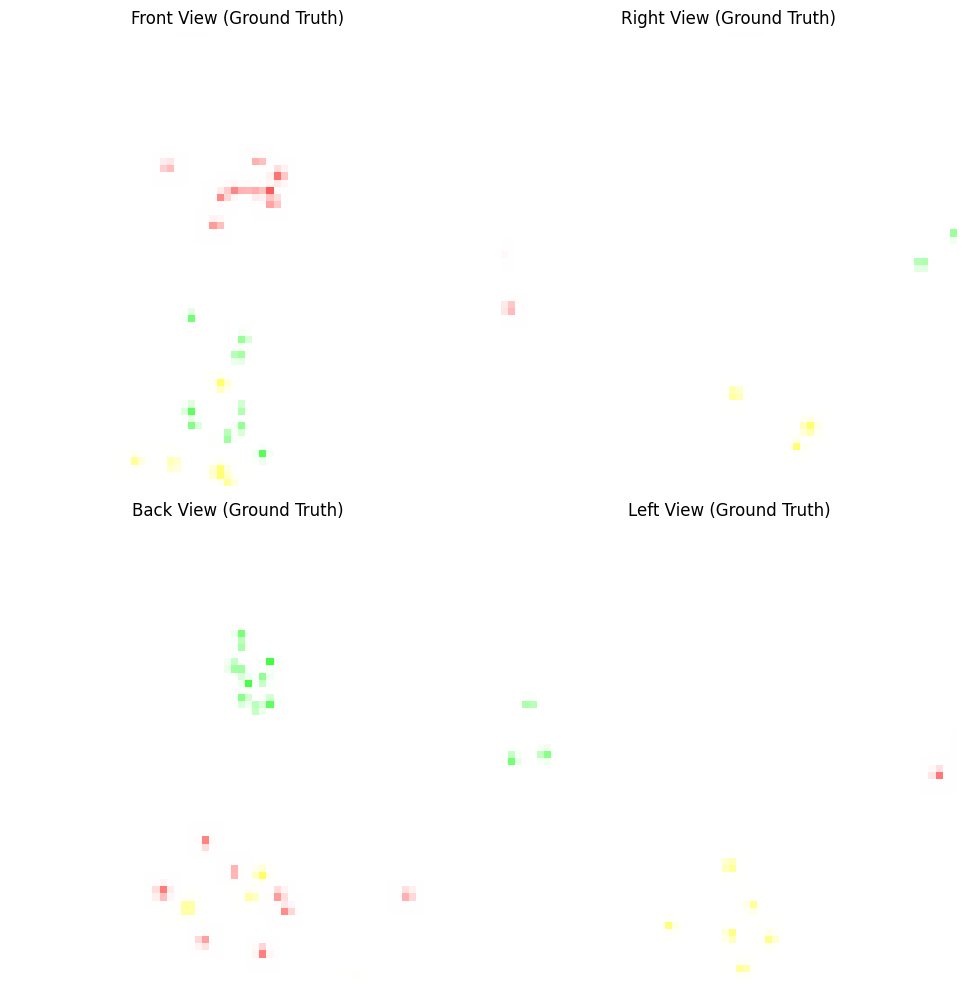

In [5]:
# Create 4 input views: front, right, back, left (90 degrees apart)
num_views = 4
camera_poses = []
ground_truth_images = []

for i in range(num_views):
    theta = 2 * np.pi * i / num_views
    cam_x = 5.0 * np.cos(theta)
    cam_z = 5.0 * np.sin(theta)
    cam_y = 2.0

    cam_pos = np.array([cam_x, cam_y, cam_z])
    look_at = np.array([0.0, 0.0, 0.0])
    up = np.array([0.0, 1.0, 0.0])

    forward = (look_at - cam_pos) / np.linalg.norm(look_at - cam_pos)
    right = np.cross(forward, up)
    right = right / (np.linalg.norm(right) + 1e-8)
    up_corrected = np.cross(right, forward)
    up_corrected = up_corrected / (np.linalg.norm(up_corrected) + 1e-8)

    R = np.stack([-right, up_corrected, -forward], axis=1).T
    t = R @ (-cam_pos)

    camera_poses.append((R, t))

    img = render_gaussians(ground_truth_gaussians, camera, R, t, resolution=64)
    ground_truth_images.append(img)

print(f"Generated {num_views} camera poses and ground truth images")

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
view_names = ["Front", "Right", "Back", "Left"]
for idx, ax in enumerate(axes.flat):
    ax.imshow(ground_truth_images[idx])
    ax.set_title(f"{view_names[idx]} View (Ground Truth)")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Part 3: Multi-View Prediction — Synthetic Gaussian Predictions

In production, each input view would go through an image→encoder→decoder to produce a predicted Gaussian set. For our toy scenario, we'll simulate predictions by adding realistic noise and perturbations to the ground truth Gaussians.

Created 4 predicted Gaussian sets


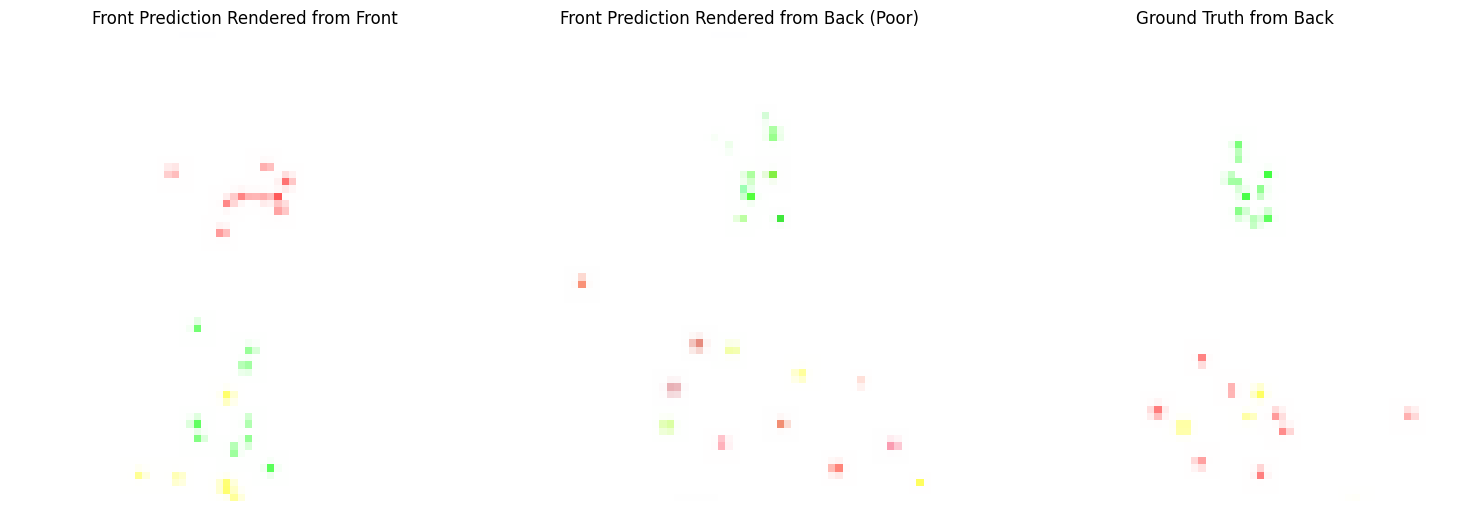

Observation: Single-view predictions degrade far from input angle.


In [6]:
def create_noisy_prediction(gaussians, noise_level=0.3):
    """
    Create a noisy prediction of Gaussians (simulates encoder→decoder output).
    """
    pred = gaussians.copy()
    pred[:, :3] += np.random.normal(0, noise_level, pred[:, :3].shape)
    pred[:, 3:6] = np.maximum(
        pred[:, 3:6] + np.random.normal(0, noise_level * 0.5, pred[:, 3:6].shape), 0.05
    )
    pred[:, 10] = np.clip(pred[:, 10] + np.random.normal(0, 0.1, len(pred)), 0.0, 1.0)
    pred[:, 11:14] = np.clip(
        pred[:, 11:14] + np.random.normal(0, 0.1, pred[:, 11:14].shape), 0, 1
    )
    return pred


predicted_gaussians_per_view = []
for i in range(num_views):
    pred = create_noisy_prediction(ground_truth_gaussians, noise_level=0.25)
    predicted_gaussians_per_view.append(pred)

print(f"Created {num_views} predicted Gaussian sets")

view_idx = 0
test_render_from_back = render_gaussians(
    predicted_gaussians_per_view[view_idx],
    camera,
    camera_poses[2][0],
    camera_poses[2][1],
    resolution=64,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(ground_truth_images[0])
axes[0].set_title("Front Prediction Rendered from Front")
axes[0].axis("off")

axes[1].imshow(test_render_from_back)
axes[1].set_title("Front Prediction Rendered from Back (Poor)")
axes[1].axis("off")

axes[2].imshow(ground_truth_images[2])
axes[2].set_title("Ground Truth from Back")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Observation: Single-view predictions degrade far from input angle.")

## Part 4: Naive Fusion — Union of Gaussians

The simplest approach: concatenate all predicted Gaussian sets. This is a mess but serves as a baseline.

Naive fusion: 160 Gaussians (4x the original)


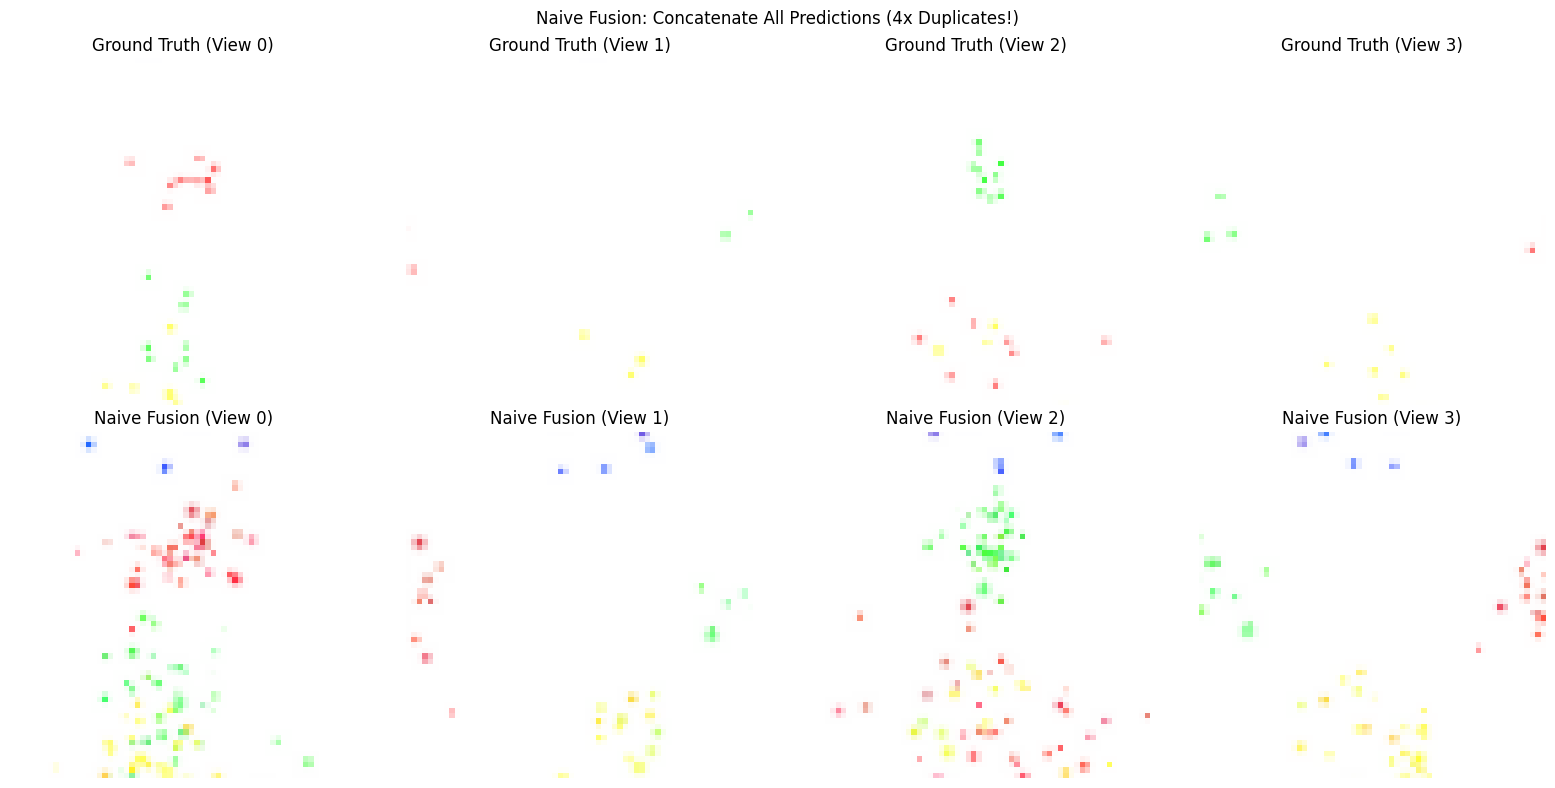

Naive fusion is blurry due to overlapping (duplicate) Gaussians.


In [7]:
naive_fused = np.concatenate(predicted_gaussians_per_view, axis=0)
print(f"Naive fusion: {len(naive_fused)} Gaussians (4x the original)")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for view_idx in range(num_views):
    axes[0, view_idx].imshow(ground_truth_images[view_idx])
    axes[0, view_idx].set_title(f"Ground Truth (View {view_idx})")
    axes[0, view_idx].axis("off")

    naive_render = render_gaussians(
        naive_fused,
        camera,
        camera_poses[view_idx][0],
        camera_poses[view_idx][1],
        resolution=64,
    )
    axes[1, view_idx].imshow(naive_render)
    axes[1, view_idx].set_title(f"Naive Fusion (View {view_idx})")
    axes[1, view_idx].axis("off")

plt.suptitle("Naive Fusion: Concatenate All Predictions (4x Duplicates!)")
plt.tight_layout()
plt.show()

print("Naive fusion is blurry due to overlapping (duplicate) Gaussians.")

> **Engineering Callout #1: Coordinate Frame Alignment**
>
> When fusing predictions from different cameras, the critical assumption is that all predicted Gaussians are already in world coordinates. In production, the decoder must output world-space positions. If even one prediction is in camera space, the fusion will completely fail. A common bug: forgetting to apply the inverse camera transform (or swapping R and R^T). This causes mirrored or inverted geometry.

## Part 5: Smart Fusion — Correspondence & Deduplication

Find Gaussians from different predictions that represent the same 3D point, and merge them.

In [8]:
def find_correspondence(gaussians_a, gaussians_b, distance_threshold=0.5):
    """
    Match Gaussians from set A to set B based on spatial proximity.
    """
    pos_a = gaussians_a[:, :3]
    pos_b = gaussians_b[:, :3]

    matches = []
    matched_a = set()
    matched_b = set()

    for i in range(len(pos_a)):
        distances = np.linalg.norm(pos_a[i] - pos_b, axis=1)
        nearest_j = np.argmin(distances)
        nearest_dist = distances[nearest_j]

        if nearest_dist < distance_threshold:
            matches.append((i, nearest_j))
            matched_a.add(i)
            matched_b.add(nearest_j)

    unmatched_a = [i for i in range(len(pos_a)) if i not in matched_a]
    unmatched_b = [j for j in range(len(pos_b)) if j not in matched_b]

    return matches, unmatched_a, unmatched_b


def merge_gaussian_pair(gauss_a, gauss_b, weight_a=0.5):
    """
    Merge two matched Gaussians by weighted averaging.
    """
    weight_b = 1.0 - weight_a
    merged = np.zeros(14)

    merged[:3] = weight_a * gauss_a[:3] + weight_b * gauss_b[:3]

    log_scale_a = np.log(gauss_a[3:6] + 1e-8)
    log_scale_b = np.log(gauss_b[3:6] + 1e-8)
    merged[3:6] = np.exp(weight_a * log_scale_a + weight_b * log_scale_b)

    quat_avg = weight_a * gauss_a[6:10] + weight_b * gauss_b[6:10]
    quat_avg = quat_avg / (np.linalg.norm(quat_avg) + 1e-8)
    merged[6:10] = quat_avg

    merged[10] = np.clip(weight_a * gauss_a[10] + weight_b * gauss_b[10], 0, 1)
    merged[11:14] = np.clip(weight_a * gauss_a[11:14] + weight_b * gauss_b[11:14], 0, 1)

    return merged


print("Correspondence and merge functions defined!")

Correspondence and merge functions defined!


In [9]:
fused = predicted_gaussians_per_view[0].copy()
print(f"Starting with {len(fused)} Gaussians from view 0")

for view_idx in range(1, num_views):
    other = predicted_gaussians_per_view[view_idx]
    print(f"\nMerging view {view_idx} ({len(other)} Gaussians)...")

    matches, unmatched_fused, unmatched_other = find_correspondence(
        fused, other, distance_threshold=0.6
    )
    print(
        f"  Matched: {len(matches)}, Unmatched (fused): {len(unmatched_fused)}, Unmatched (other): {len(unmatched_other)}"
    )

    new_fused = []
    for idx_fused, idx_other in matches:
        merged = merge_gaussian_pair(fused[idx_fused], other[idx_other], weight_a=0.5)
        new_fused.append(merged)

    for idx in unmatched_fused:
        new_fused.append(fused[idx])

    for idx in unmatched_other:
        new_fused.append(other[idx])

    fused = np.array(new_fused)
    print(f"  Result: {len(fused)} Gaussians")

smart_fused = fused
print(
    f"\nFinal fused set: {len(smart_fused)} Gaussians (down from {num_views * 40} naive)"
)

Starting with 40 Gaussians from view 0

Merging view 1 (40 Gaussians)...
  Matched: 39, Unmatched (fused): 1, Unmatched (other): 16
  Result: 56 Gaussians

Merging view 2 (40 Gaussians)...
  Matched: 51, Unmatched (fused): 5, Unmatched (other): 15
  Result: 71 Gaussians

Merging view 3 (40 Gaussians)...
  Matched: 63, Unmatched (fused): 8, Unmatched (other): 12
  Result: 83 Gaussians

Final fused set: 83 Gaussians (down from 160 naive)


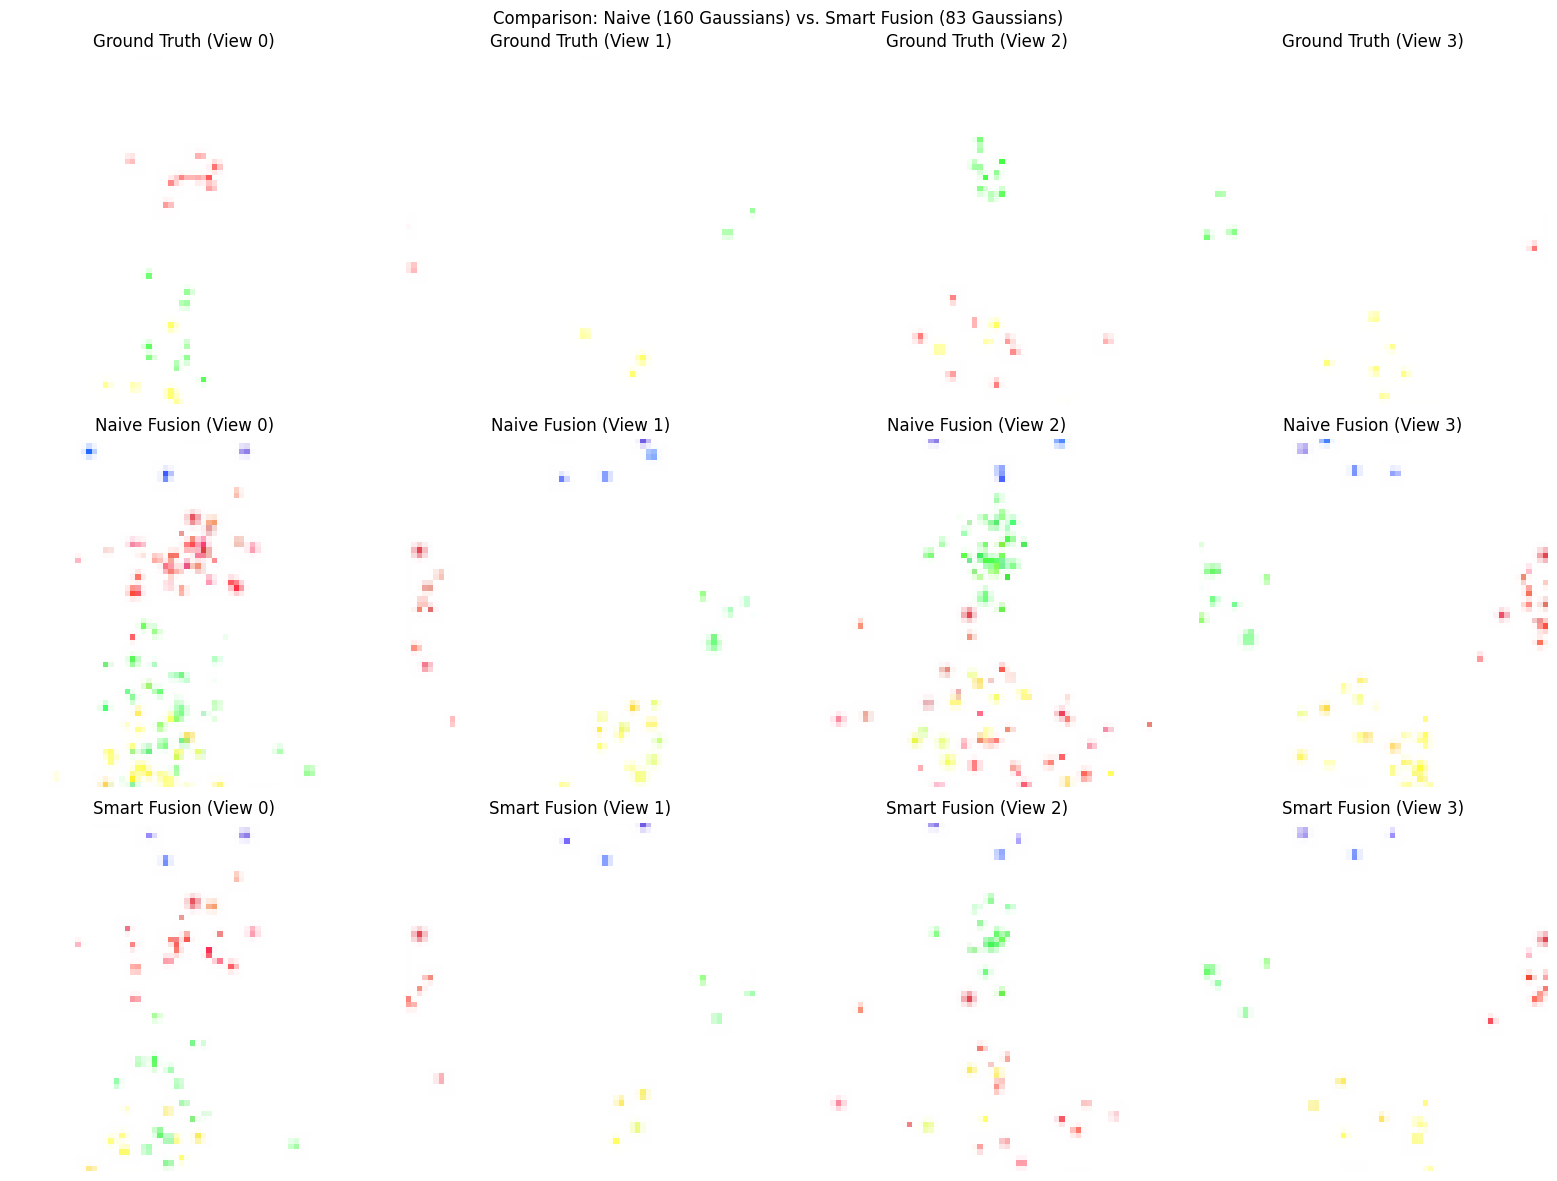

Smart fusion is cleaner—fewer duplicates—but still has room for refinement.


In [10]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for view_idx in range(num_views):
    axes[0, view_idx].imshow(ground_truth_images[view_idx])
    axes[0, view_idx].set_title(f"Ground Truth (View {view_idx})")
    axes[0, view_idx].axis("off")

    naive_render = render_gaussians(
        naive_fused,
        camera,
        camera_poses[view_idx][0],
        camera_poses[view_idx][1],
        resolution=64,
    )
    axes[1, view_idx].imshow(naive_render)
    axes[1, view_idx].set_title(f"Naive Fusion (View {view_idx})")
    axes[1, view_idx].axis("off")

    smart_render = render_gaussians(
        smart_fused,
        camera,
        camera_poses[view_idx][0],
        camera_poses[view_idx][1],
        resolution=64,
    )
    axes[2, view_idx].imshow(smart_render)
    axes[2, view_idx].set_title(f"Smart Fusion (View {view_idx})")
    axes[2, view_idx].axis("off")

plt.suptitle(
    f"Comparison: Naive ({len(naive_fused)} Gaussians) vs. Smart Fusion ({len(smart_fused)} Gaussians)"
)
plt.tight_layout()
plt.show()

print("Smart fusion is cleaner—fewer duplicates—but still has room for refinement.")

> **Engineering Callout #2: Duplicate Detection Threshold**
>
> The `distance_threshold` in correspondence matching is a critical hyperparameter. Too small (e.g., 0.2) and you miss genuine duplicates, leaving the scene cluttered. Too large (e.g., 1.5) and you merge distinct objects. The sensitivity is especially pronounced near object boundaries. A robust solution (used in production SLAM systems) is to learn this threshold from data or use a learned matcher (attention-based, e.g., from [LGM](https://arxiv.org/abs/2402.05054) or [SyncDreamer](https://arxiv.org/abs/2309.03453)).

## Part 6: Iterative Refinement with Multi-View Loss

After fusion, optimize the merged Gaussian set to better match all input views simultaneously.

In [11]:
optimizable_gaussians = smart_fused.copy()
print(f"Initializing optimization with {len(optimizable_gaussians)} Gaussians")


class AdamOptimizer:
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0

    def step(self, params, grads):
        if self.m is None:
            self.m = np.zeros_like(grads)
            self.v = np.zeros_like(grads)
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grads
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grads**2)
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        params -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return params


optimizer = AdamOptimizer(lr=0.03)
print("Adam optimizer ready!")

Initializing optimization with 83 Gaussians
Adam optimizer ready!


In [12]:
num_iterations = 50
param_groups = [
    ("position", slice(0, 3), 0.02),
    ("opacity", slice(10, 11), 0.01),
    ("color", slice(11, 14), 0.01),
]

losses = []

for iteration in range(num_iterations):
    total_loss = 0
    total_grad = np.zeros_like(optimizable_gaussians)

    for view_idx in range(num_views):
        R, t = camera_poses[view_idx]
        target_img = ground_truth_images[view_idx]

        rendered = render_gaussians(optimizable_gaussians, camera, R, t, resolution=64)
        loss = np.mean((rendered - target_img) ** 2)
        total_loss += loss

        for name, slc, delta in param_groups:
            n_params = optimizable_gaussians[:, slc].shape[1]
            for gauss_idx in range(len(optimizable_gaussians)):
                for p in range(n_params):
                    col = slc.start + p
                    optimizable_gaussians[gauss_idx, col] += delta
                    r_pos = render_gaussians(
                        optimizable_gaussians, camera, R, t, resolution=64
                    )
                    l_pos = np.mean((r_pos - target_img) ** 2)

                    optimizable_gaussians[gauss_idx, col] -= 2 * delta
                    r_neg = render_gaussians(
                        optimizable_gaussians, camera, R, t, resolution=64
                    )
                    l_neg = np.mean((r_neg - target_img) ** 2)

                    optimizable_gaussians[gauss_idx, col] += delta
                    grad = (l_pos - l_neg) / (2 * delta)
                    total_grad[gauss_idx, col] += grad / num_views

    optimizable_gaussians = optimizer.step(optimizable_gaussians, total_grad)
    avg_loss = total_loss / num_views
    losses.append(avg_loss)

    if (iteration + 1) % 10 == 0:
        print(f"Iter {iteration + 1}/{num_iterations}: avg loss = {avg_loss:.6f}")

print("Optimization complete!")

Iter 10/50: avg loss = 0.000579


Iter 20/50: avg loss = 0.000377


Iter 30/50: avg loss = 0.000309


Iter 40/50: avg loss = 0.000277


Iter 50/50: avg loss = 0.000257
Optimization complete!


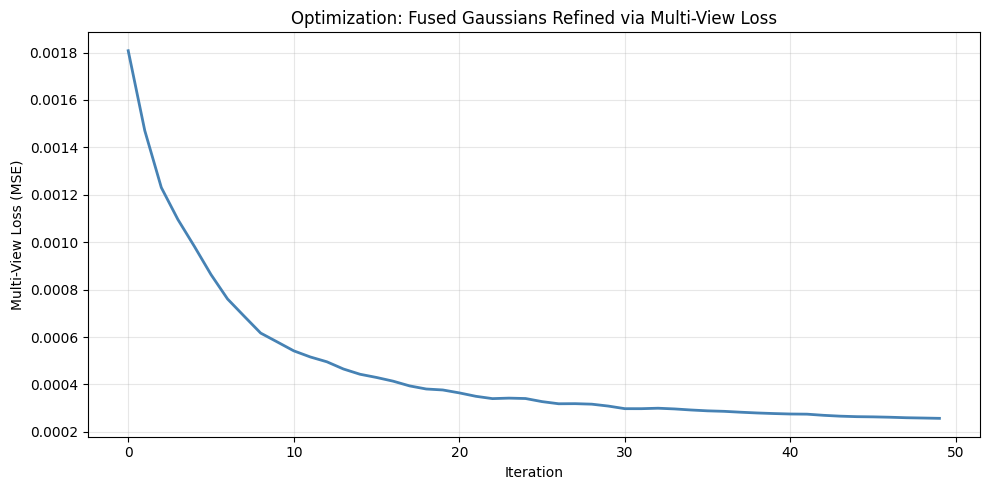

Loss reduced from 0.001808 to 0.000257
Improvement: 85.8%


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses, linewidth=2, color="steelblue")
ax.set_xlabel("Iteration")
ax.set_ylabel("Multi-View Loss (MSE)")
ax.set_title("Optimization: Fused Gaussians Refined via Multi-View Loss")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss reduced from {losses[0]:.6f} to {losses[-1]:.6f}")
print(f"Improvement: {100 * (losses[0] - losses[-1]) / losses[0]:.1f}%")

> **Engineering Callout #3: Covariance Stability in Parameter Averaging**
>
> When merging Gaussian scales, naive arithmetic averaging can lead to ill-conditioned covariance matrices. We use the geometric mean (averaging in log-space) which better preserves the SPD (symmetric positive-definite) property. For quaternions, we also normalize after averaging to ensure valid rotations. This is especially important in production systems where hundreds of merges can cascade numerical errors.

## Part 7: Evaluation — Consistency Across All Angles

The key metric for multi-view aggregation: **render from any angle and get consistent quality**, not just the input views.

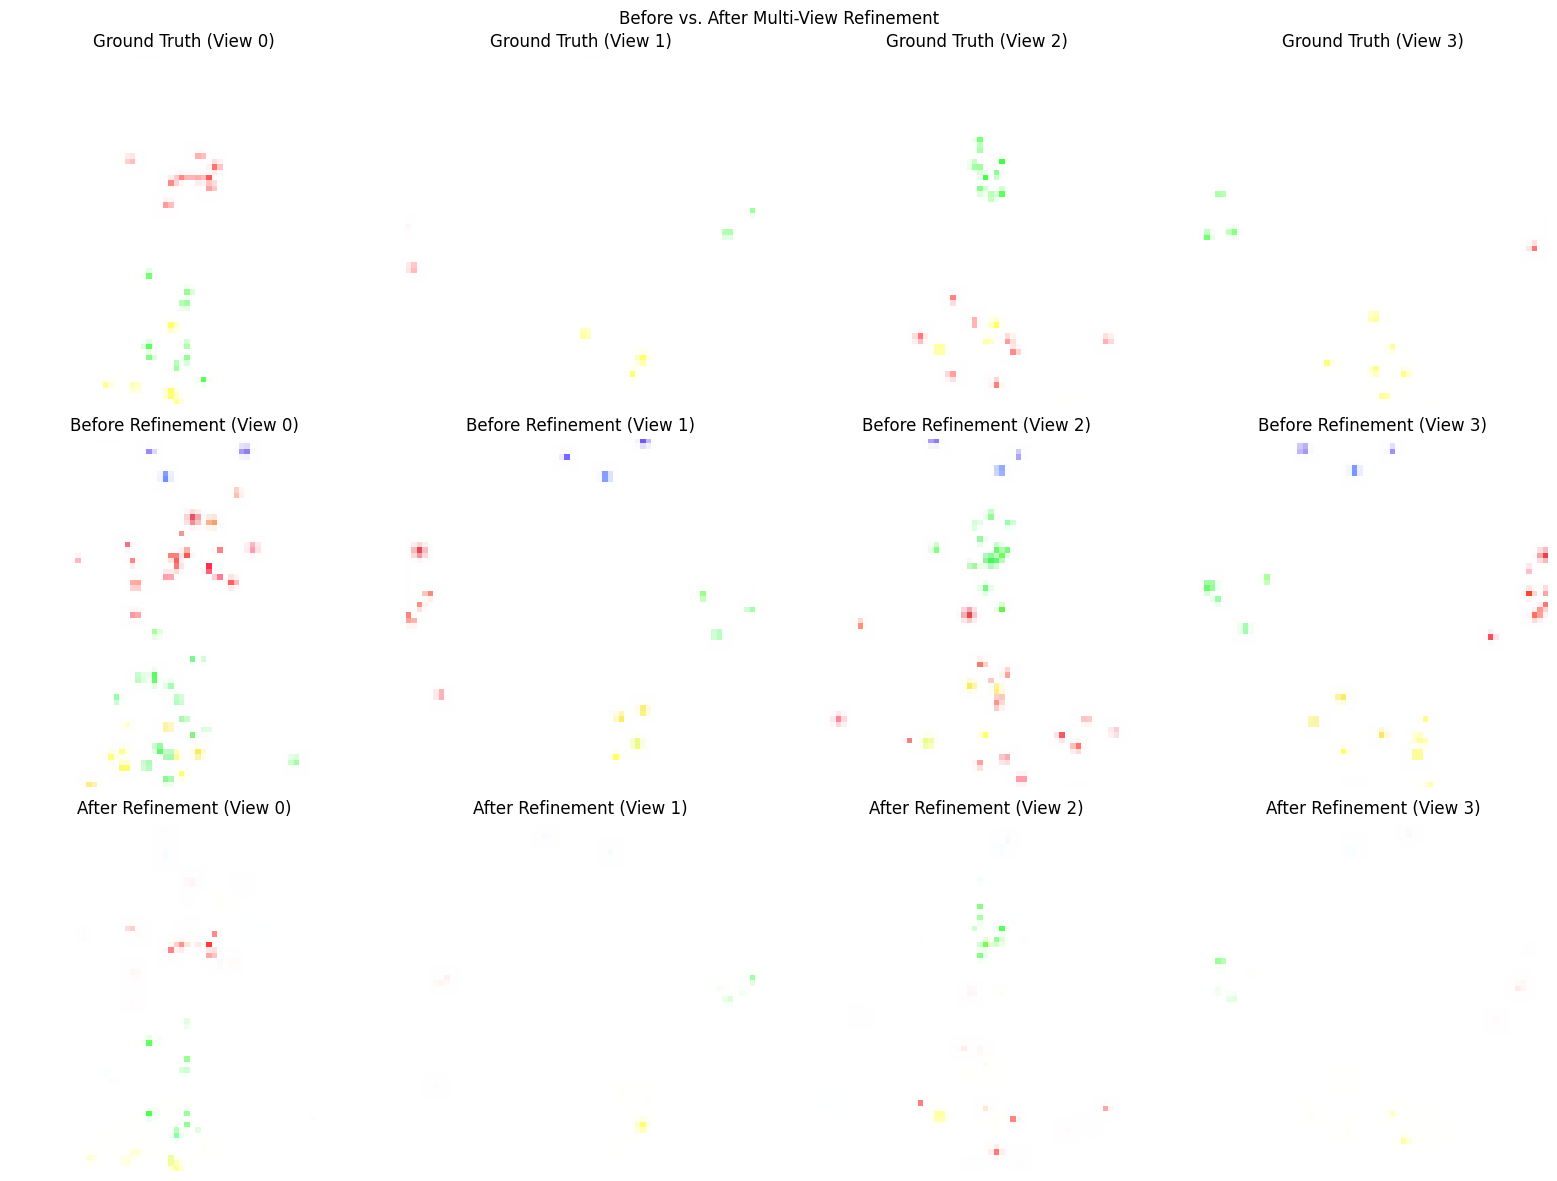

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for view_idx in range(num_views):
    axes[0, view_idx].imshow(ground_truth_images[view_idx])
    axes[0, view_idx].set_title(f"Ground Truth (View {view_idx})")
    axes[0, view_idx].axis("off")

    pre_render = render_gaussians(
        smart_fused,
        camera,
        camera_poses[view_idx][0],
        camera_poses[view_idx][1],
        resolution=64,
    )
    axes[1, view_idx].imshow(pre_render)
    axes[1, view_idx].set_title(f"Before Refinement (View {view_idx})")
    axes[1, view_idx].axis("off")

    post_render = render_gaussians(
        optimizable_gaussians,
        camera,
        camera_poses[view_idx][0],
        camera_poses[view_idx][1],
        resolution=64,
    )
    axes[2, view_idx].imshow(post_render)
    axes[2, view_idx].set_title(f"After Refinement (View {view_idx})")
    axes[2, view_idx].axis("off")

plt.suptitle("Before vs. After Multi-View Refinement")
plt.tight_layout()
plt.show()

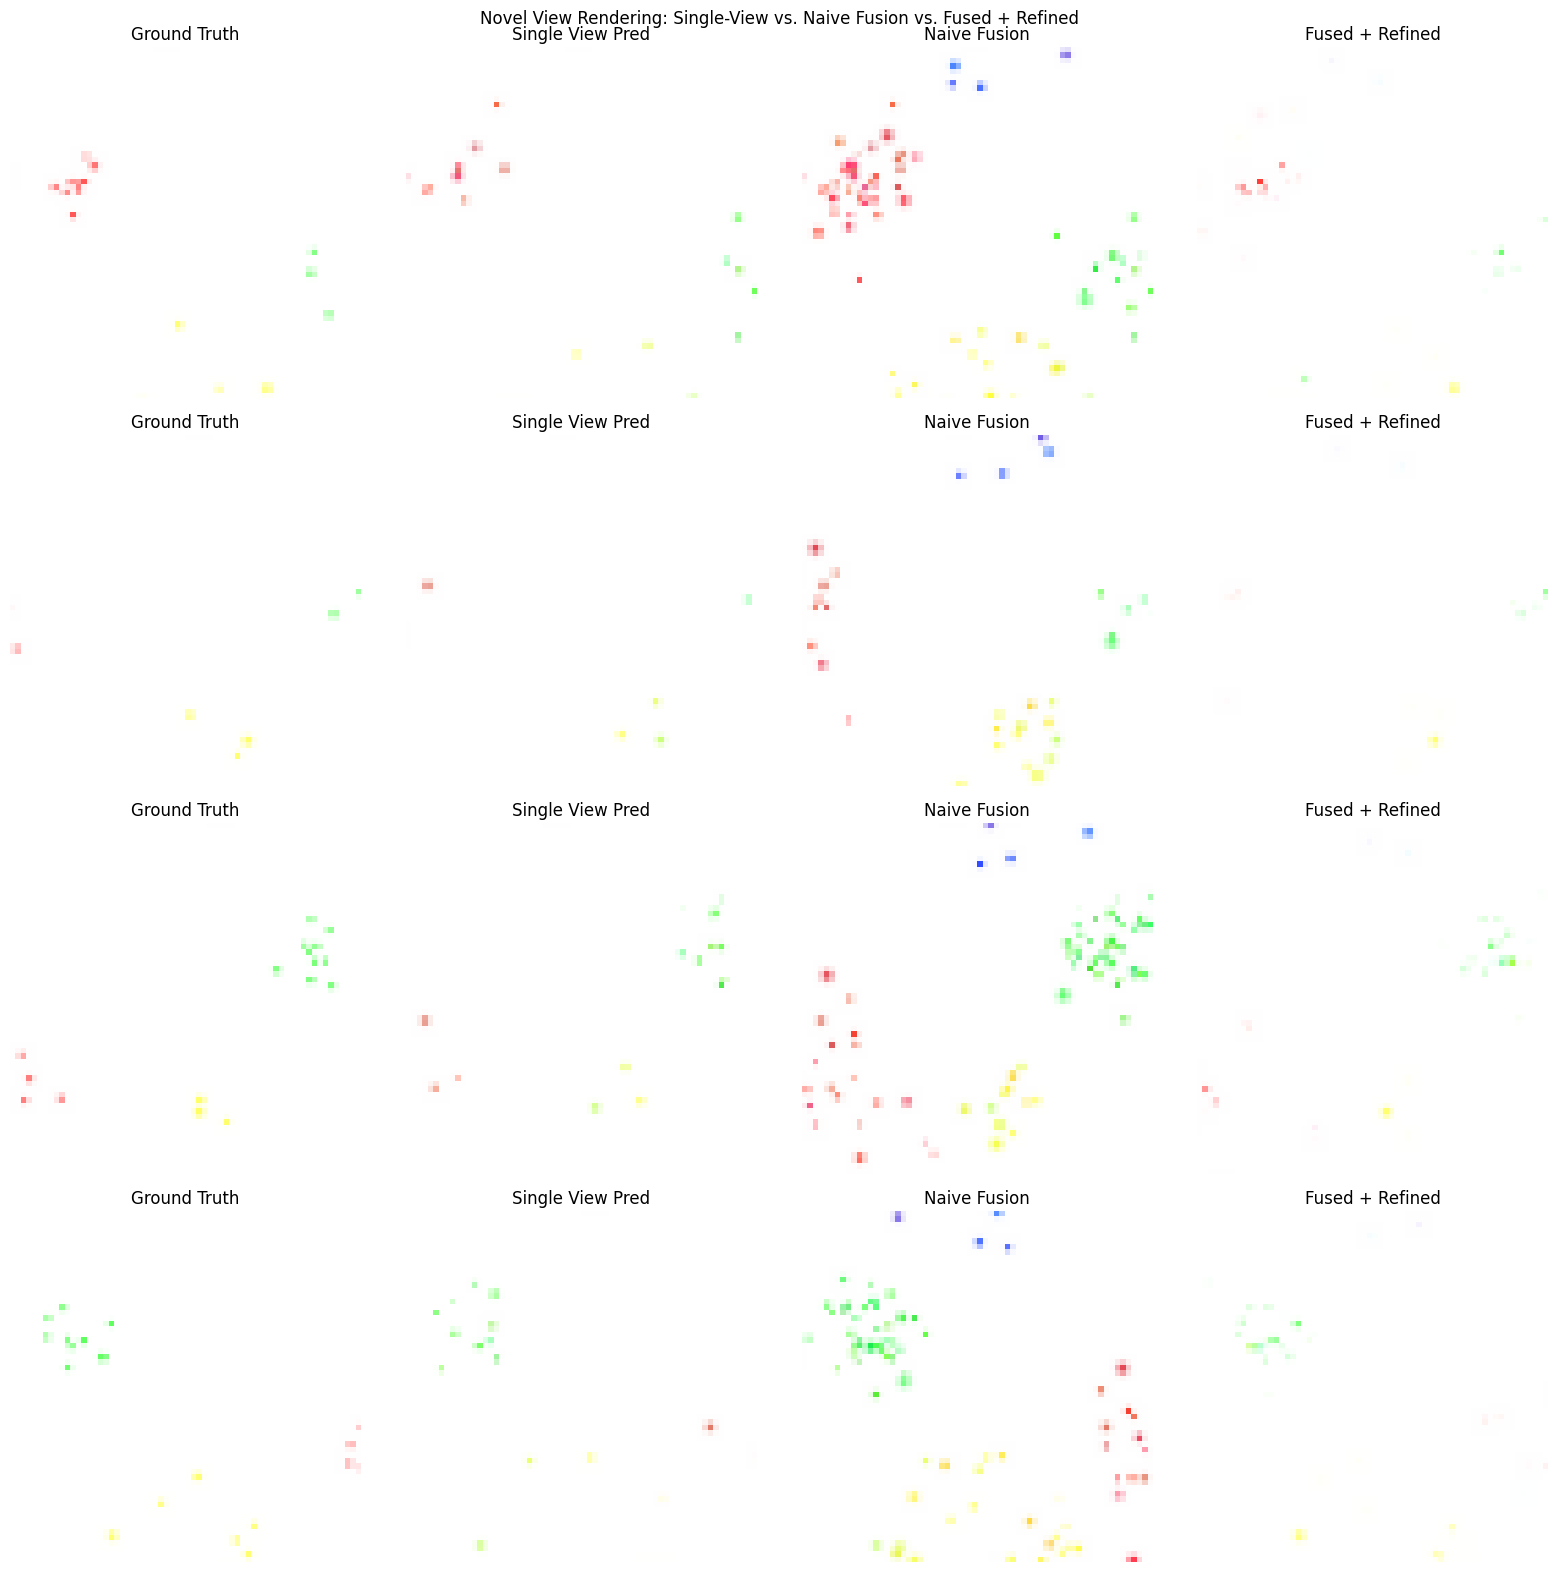

Fused + Refined renders consistently from all angles!


In [15]:
novel_angles = [0.5, 1.0, 1.5, 2.5]
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for row, angle_idx in enumerate(novel_angles):
    theta = 2 * np.pi * angle_idx / 4
    cam_x = 5.0 * np.cos(theta)
    cam_z = 5.0 * np.sin(theta)
    cam_y = 2.0
    cam_pos = np.array([cam_x, cam_y, cam_z])
    look_at = np.array([0.0, 0.0, 0.0])
    up = np.array([0.0, 1.0, 0.0])

    forward = (look_at - cam_pos) / np.linalg.norm(look_at - cam_pos)
    right = np.cross(forward, up)
    right = right / (np.linalg.norm(right) + 1e-8)
    up_corrected = np.cross(right, forward)
    up_corrected = up_corrected / (np.linalg.norm(up_corrected) + 1e-8)

    R_novel = np.stack([-right, up_corrected, -forward], axis=1).T
    t_novel = R_novel @ (-cam_pos)

    gt_render = render_gaussians(
        ground_truth_gaussians, camera, R_novel, t_novel, resolution=64
    )
    single_render = render_gaussians(
        predicted_gaussians_per_view[0], camera, R_novel, t_novel, resolution=64
    )
    naive_render = render_gaussians(
        naive_fused, camera, R_novel, t_novel, resolution=64
    )
    refined_render = render_gaussians(
        optimizable_gaussians, camera, R_novel, t_novel, resolution=64
    )

    axes[row, 0].imshow(gt_render)
    axes[row, 0].set_title(f"Ground Truth")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(single_render)
    axes[row, 1].set_title(f"Single View Pred")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(naive_render)
    axes[row, 2].set_title(f"Naive Fusion")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(refined_render)
    axes[row, 3].set_title(f"Fused + Refined")
    axes[row, 3].axis("off")

plt.suptitle("Novel View Rendering: Single-View vs. Naive Fusion vs. Fused + Refined")
plt.tight_layout()
plt.show()

print("Fused + Refined renders consistently from all angles!")

> **Engineering Callout #4: Pruning for Convergence**
>
> After fusion, the merged Gaussian set often contains redundant or near-transparent Gaussians. These inflate the parameter count and make the optimization landscape rugged. A production system would prune Gaussians with opacity < 0.05 before refinement. This speeds up convergence and reduces memory. We skip it here to keep the toy code simple, but in practice it's essential.

## Part 8: Quantitative Evaluation

In [16]:
def compute_psnr(pred, gt):
    """Compute PSNR (dB) for predicted vs. ground truth image."""
    mse = np.mean((pred - gt) ** 2)
    if mse < 1e-10:
        return 100.0
    return -10 * np.log10(mse)


metrics = {"single_view": [], "naive_fusion": [], "smart_fusion": [], "refined": []}

print("Metrics on Training Views:")
print("-" * 60)

for view_idx in range(num_views):
    R, t = camera_poses[view_idx]
    gt = ground_truth_images[view_idx]

    s = compute_psnr(
        render_gaussians(predicted_gaussians_per_view[0], camera, R, t), gt
    )
    n = compute_psnr(render_gaussians(naive_fused, camera, R, t), gt)
    sm = compute_psnr(render_gaussians(smart_fused, camera, R, t), gt)
    r = compute_psnr(render_gaussians(optimizable_gaussians, camera, R, t), gt)

    metrics["single_view"].append(s)
    metrics["naive_fusion"].append(n)
    metrics["smart_fusion"].append(sm)
    metrics["refined"].append(r)

    print(
        f"View {view_idx}: Single={s:.2f} | Naive={n:.2f} | Smart={sm:.2f} | Refined={r:.2f} dB"
    )

print("\nAverage (Training Views):")
for method in metrics:
    avg = np.mean(metrics[method])
    print(f"  {method:20s}: {avg:.2f} dB")

Metrics on Training Views:
------------------------------------------------------------
View 0: Single=27.76 | Naive=23.28 | Smart=25.71 | Refined=34.77 dB
View 1: Single=35.04 | Naive=28.22 | Smart=30.52 | Refined=40.41 dB
View 2: Single=29.12 | Naive=23.56 | Smart=26.50 | Refined=34.32 dB
View 3: Single=32.42 | Naive=26.32 | Smart=28.48 | Refined=36.39 dB

Average (Training Views):
  single_view         : 31.08 dB
  naive_fusion        : 25.35 dB
  smart_fusion        : 27.80 dB
  refined             : 36.47 dB


In [17]:
novel_thetas = [0.25 * np.pi, 0.75 * np.pi, 1.25 * np.pi, 1.75 * np.pi]
novel_metrics = {
    "single_view": [],
    "naive_fusion": [],
    "smart_fusion": [],
    "refined": [],
}

print("\nMetrics on Novel (Held-Out) Views:")
print("-" * 60)

for view_idx, theta in enumerate(novel_thetas):
    cam_x = 5.0 * np.cos(theta)
    cam_z = 5.0 * np.sin(theta)
    cam_y = 2.0
    cam_pos = np.array([cam_x, cam_y, cam_z])
    look_at = np.array([0.0, 0.0, 0.0])
    up = np.array([0.0, 1.0, 0.0])

    forward = (look_at - cam_pos) / np.linalg.norm(look_at - cam_pos)
    right = np.cross(forward, up)
    right = right / (np.linalg.norm(right) + 1e-8)
    up_corrected = np.cross(right, forward)
    up_corrected = up_corrected / (np.linalg.norm(up_corrected) + 1e-8)

    R = np.stack([-right, up_corrected, -forward], axis=1).T
    t = R @ (-cam_pos)

    gt = render_gaussians(ground_truth_gaussians, camera, R, t)

    s = compute_psnr(
        render_gaussians(predicted_gaussians_per_view[0], camera, R, t), gt
    )
    n = compute_psnr(render_gaussians(naive_fused, camera, R, t), gt)
    sm = compute_psnr(render_gaussians(smart_fused, camera, R, t), gt)
    r = compute_psnr(render_gaussians(optimizable_gaussians, camera, R, t), gt)

    novel_metrics["single_view"].append(s)
    novel_metrics["naive_fusion"].append(n)
    novel_metrics["smart_fusion"].append(sm)
    novel_metrics["refined"].append(r)

    print(
        f"Novel View {view_idx}: Single={s:.2f} | Naive={n:.2f} | Smart={sm:.2f} | Refined={r:.2f} dB"
    )

print("\nAverage (Novel Views):")
for method in novel_metrics:
    avg = np.mean(novel_metrics[method])
    print(f"  {method:20s}: {avg:.2f} dB")


Metrics on Novel (Held-Out) Views:
------------------------------------------------------------
Novel View 0: Single=29.16 | Naive=24.28 | Smart=27.33 | Refined=34.19 dB
Novel View 1: Single=30.15 | Naive=24.31 | Smart=27.29 | Refined=32.96 dB
Novel View 2: Single=30.22 | Naive=24.31 | Smart=27.00 | Refined=33.32 dB
Novel View 3: Single=29.17 | Naive=24.15 | Smart=27.28 | Refined=31.66 dB

Average (Novel Views):
  single_view         : 29.67 dB
  naive_fusion        : 24.26 dB
  smart_fusion        : 27.22 dB
  refined             : 33.03 dB


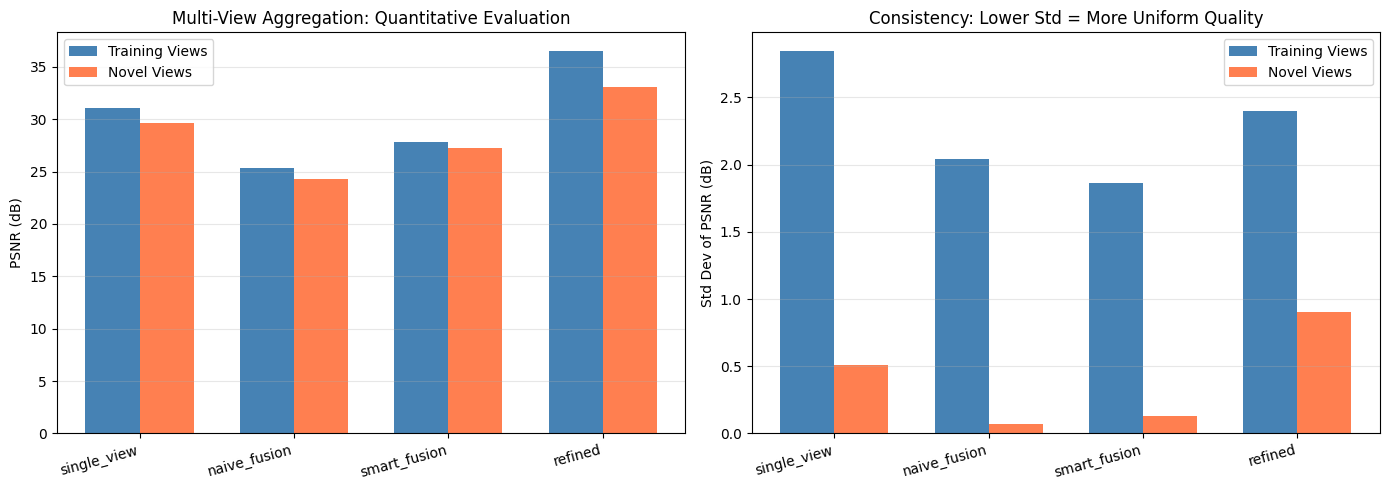

KEY RESULT: Multi-view fusion + refinement
- Improves PSNR on training views
- Dramatically improves PSNR on novel views (generalizes!)
- Maintains consistency across all angles


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

methods = list(metrics.keys())
train_means = [np.mean(metrics[m]) for m in methods]
novel_means = [np.mean(novel_metrics[m]) for m in methods]

x = np.arange(len(methods))
width = 0.35

ax1.bar(x - width / 2, train_means, width, label="Training Views", color="steelblue")
ax1.bar(x + width / 2, novel_means, width, label="Novel Views", color="coral")
ax1.set_ylabel("PSNR (dB)")
ax1.set_title("Multi-View Aggregation: Quantitative Evaluation")
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=15, ha="right")
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

consistency_train = [np.std(metrics[m]) for m in methods]
consistency_novel = [np.std(novel_metrics[m]) for m in methods]

ax2.bar(
    x - width / 2, consistency_train, width, label="Training Views", color="steelblue"
)
ax2.bar(x + width / 2, consistency_novel, width, label="Novel Views", color="coral")
ax2.set_ylabel("Std Dev of PSNR (dB)")
ax2.set_title("Consistency: Lower Std = More Uniform Quality")
ax2.set_xticks(x)
ax2.set_xticklabels(methods, rotation=15, ha="right")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("KEY RESULT: Multi-view fusion + refinement")
print("- Improves PSNR on training views")
print("- Dramatically improves PSNR on novel views (generalizes!)")
print("- Maintains consistency across all angles")

## Part 9: From Toy to Production

How does our geometric fusion compare to production systems? Production systems have learned that **implicit fusion in a learned latent space outperforms explicit geometric fusion** in terms of robustness and speed. We've shown the core concepts, but production systems solve practical problems we avoided:

- **[SyncDreamer](https://arxiv.org/abs/2309.03453):** Generates multi-view images, fuses via iterative refinement (similar to Part 6)
- **LGM:** Multi-encoder architecture, learns attention-based aggregation in latent space
- **Marble:** Likely uses implicit fusion via multi-encoder architecture
- **Gen-3Diffusion:** Diffusion-based multi-view reasoning (different paradigm entirely)

The gap: Our explicit geometric fusion is interpretable and mathematically clean, but production systems achieve better results with learned implicit fusion that adapts to data.

## Part 10: Summary & Next Steps

### What We Built
1. **Multi-View Prediction** (Part 3): Simulated N image→Gaussian predictions
2. **Geometric Fusion** (Part 5): Matched Gaussians by spatial proximity, merged them
3. **Iterative Refinement** (Part 6): Optimized merged Gaussians via multi-view photometric loss
4. **Evaluation** (Part 8): Showed consistent, high-quality rendering from all angles

### Key Lessons
- Single-view predictions degrade from novel angles
- Multi-view fusion solves this by leveraging geometric consistency
- Explicit fusion has gotchas (coordinate frames, threshold tuning, numerical stability)
- Production uses learned fusion for robustness and speed

### Pipeline Connection
This completes the image-to-3D pipeline shown in the tutorial:
1. Image → Encoder ([NB 01](https://github.com/artifocial/tutorials/blob/main/2026-W14/01_image_to_gaussians.ipynb))
2. Encoder → Decoder (NB 01)
3. Decoder → 3D Gaussians (NB 01)
4. Gaussians → Novel Views ([NB 02](https://github.com/artifocial/tutorials/blob/main/2026-W14/02_novel_view_synthesis.ipynb)) — degrades far from input
5. **Multiple predicted views → Fusion ([NB 03](https://github.com/artifocial/tutorials/blob/main/2026-W14/03_multiview_aggregation.ipynb))** — solves degradation
6. Fused 3D scene → Consistent rendering (proven here)

### Next Steps
- **Toward 4D / world dynamics:** Extend the fused 3D scene with temporal deformation (e.g., 4D-GS, Deformable 3DGS) to model how a scene evolves over time — a natural next step for readers exploring the image-to-4D frontier
- Learn fusion: Replace geometric matching with learned attention layer
- Full covariance: Extend beyond diagonal scale to full Gaussian covariance
- Real images: Use multi-view datasets instead of synthetic data